# Specific Stock Simulation


In [19]:
import matplotlib.pyplot as plt
import analysis_interfaces.interface_specific_stock as iss


## Block 1: Parameters


In [20]:
ticker = "TSLA"
initial_funds = 100
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency

period = "1y"  # Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max

## Block 4: Simulate Daily Buy/Sell/Hold Strategy


In [21]:
df_pred = iss.build_prediction_and_stats(
            ticker,
            include_sentiment=include_sentiment,
            period=period,
        )

In [22]:
simulation_result = iss.simulate_prediction_signal_strategy(
    df_pred,
    initial_funds=initial_funds,
)


## Block 5: Portfolio Summary


In [23]:
df_pred

,Date,Open,High,Low,Close,Adj Close,Volume,TICKER,SMA10,SMA20,...,Daily Gain/Loss,technical_analysis_buy_score,technical_analysis_sell_score,fundamental_snapshot_report_date,fundamental_snapshot_available_from,fundamental_analysis_score,sentiment_analysis_score,multifactor_analysis_score,Signal,Signal_Text
0,2026-03-16,396.220001,403.730011,394.420013,395.559998,395.559998,56545394,TSLA,398.816000,403.733000,...,-0.660004,0.05,-0.70,2025-12-31,2026-02-14,0.2,0.0,0.00875,-0.143613,WEAK SELL
1,2026-03-13,399.170013,400.200012,389.950012,391.200012,391.200012,58337700,TSLA,399.592001,404.827000,...,-7.970001,0.05,-0.70,2025-12-31,2026-02-14,0.2,0.0,0.00875,-0.143613,WEAK SELL
2,2026-03-12,405.179993,406.500000,394.649994,395.010010,395.010010,60973800,TSLA,400.723001,406.120500,...,-10.169983,0.05,-0.70,2025-12-31,2026-02-14,0.2,0.0,0.01875,-0.140313,WEAK SELL
3,2026-03-11,402.279999,416.380005,402.149994,407.820007,407.820007,62559900,TSLA,402.079999,407.783499,...,5.540009,0.05,-0.70,2025-12-31,2026-02-14,0.2,0.0,0.01875,-0.140313,WEAK SELL
4,2026-03-10,402.220001,406.589996,398.190002,399.239990,399.239990,59258700,TSLA,403.037997,408.652998,...,-2.980011,0.05,-0.70,2025-12-31,2026-02-14,0.2,0.0,0.01875,-0.140313,WEAK SELL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,2025-03-21,234.990005,249.520004,234.550003,248.710007,248.710007,132728700,TSLA,NaN,NaN,...,13.720001,0.35,-0.20,2024-12-31,2025-02-14,0.2,0.0,0.02500,0.125750,WEAK BUY
247,2025-03-20,233.350006,238.000000,230.050003,236.259995,236.259995,99028300,TSLA,NaN,NaN,...,2.909988,0.00,-0.55,2024-12-31,2025-02-14,0.2,0.0,0.01625,-0.108138,WEAK SELL
248,2025-03-19,231.610001,241.410004,229.199997,235.860001,235.860001,111993800,TSLA,NaN,NaN,...,4.250000,0.00,-0.55,2024-12-31,2025-02-14,0.2,0.0,0.01625,-0.108138,WEAK SELL
249,2025-03-18,228.160004,230.100006,222.279999,225.309998,225.309998,111477600,TSLA,NaN,NaN,...,-2.850006,0.10,-0.45,2024-12-31,2025-02-14,0.2,0.0,0.02625,-0.038837,HOLD


In [24]:
simulation_result["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value
0,2025-03-21,BUY,WEAK BUY,241.850006,0.020674,5.000000,95.000000,0.020674,100.141823
1,2025-03-24,BUY,WEAK BUY,268.235001,0.018640,5.000000,90.000000,0.039314,100.944720
2,2025-03-25,BUY,WEAK BUY,285.870010,0.017490,5.000000,85.000000,0.056805,101.367739
3,2025-03-26,BUY,WEAK BUY,277.360001,0.018027,5.000000,80.000000,0.074832,100.358773
4,2025-03-27,BUY,WEAK BUY,272.805008,0.018328,5.000000,75.000000,0.093160,100.444800
...,...,...,...,...,...,...,...,...,...
83,2026-03-10,SELL,WEAK SELL,400.729996,0.004929,1.975267,109.897614,0.093654,147.288136
84,2026-03-11,SELL,WEAK SELL,405.050003,0.004683,1.896733,111.794346,0.088972,148.078720
85,2026-03-12,SELL,WEAK SELL,400.095001,0.004449,1.779853,113.574200,0.084523,146.961616
86,2026-03-13,SELL,WEAK SELL,395.185013,0.004226,1.670110,115.244310,0.080297,146.656425


In [25]:
simulation_result["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,2025-03-17,2026-03-16,100.0,116.833745,0.076282,330.471272,395.559998,30.174097,147.007843,47.007843,47.007843,40,48


## Block 6: Consolidated Chart


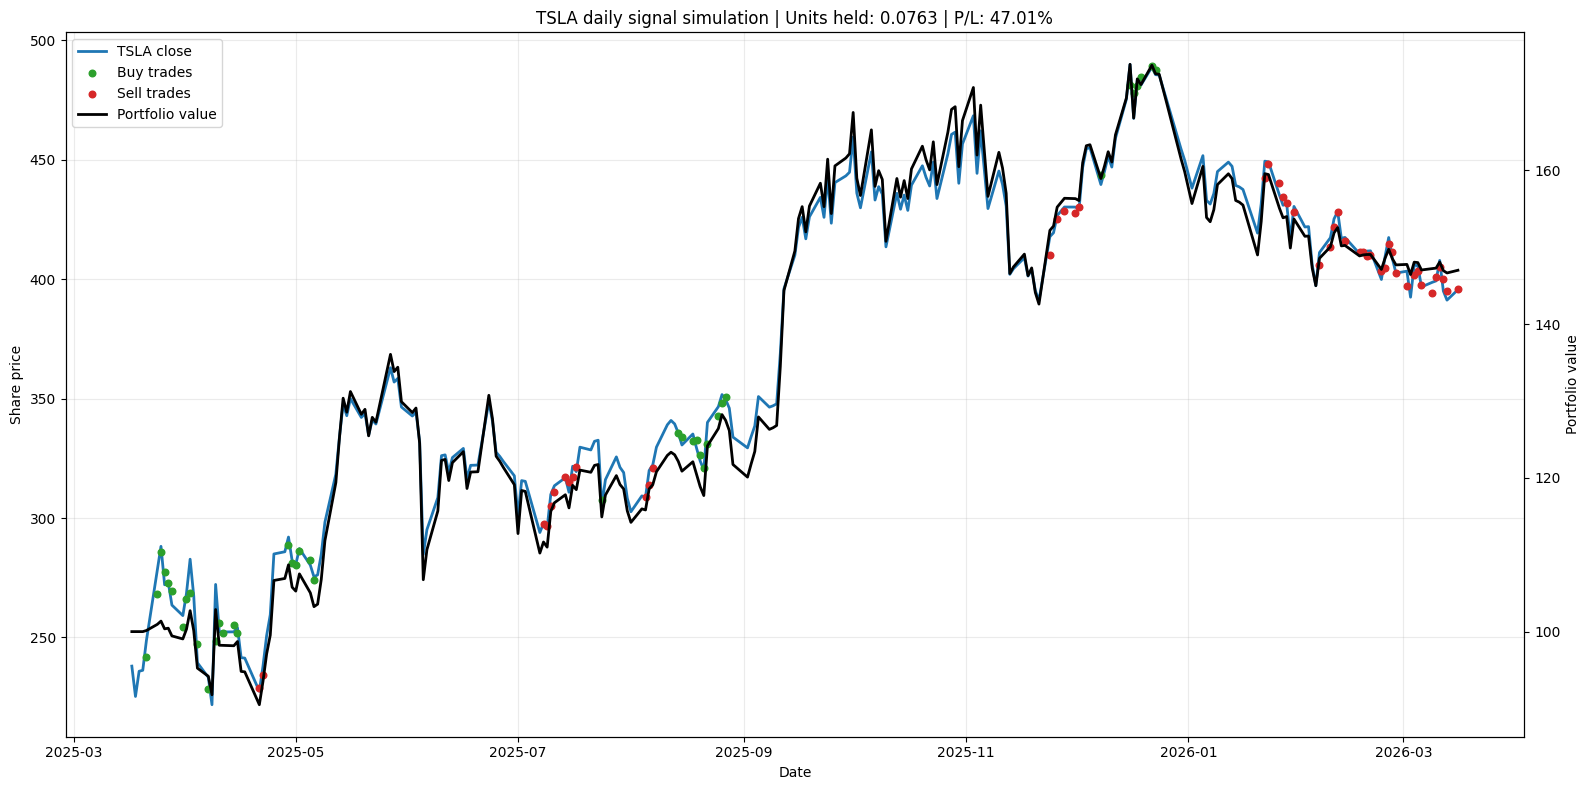

In [26]:
price_history = simulation_result["price_history"].copy()
daily_history = simulation_result["daily_history"].copy()
transactions = simulation_result["transactions"].copy()
simulation_summary = simulation_result["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 8))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker=".",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker=".",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#000000",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value")

title = (
    f"{ticker} daily signal simulation | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 7: Daily Portfolio History


In [27]:
simulation_result["daily_history"][[
    "Date",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]]


,Date,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
0,2025-03-17,HOLD,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
1,2025-03-18,HOLD,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
2,2025-03-19,WEAK SELL,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
3,2025-03-20,WEAK SELL,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
4,2025-03-21,WEAK BUY,BUY,0.020674,5.000000,95.000000,0.020674,5.141823,100.141823,0.141823
...,...,...,...,...,...,...,...,...,...,...
246,2026-03-10,WEAK SELL,SELL,0.004929,1.975267,109.897614,0.093654,37.390523,147.288136,47.288136
247,2026-03-11,WEAK SELL,SELL,0.004683,1.896733,111.794346,0.088972,36.284374,148.078720,48.078720
248,2026-03-12,WEAK SELL,SELL,0.004449,1.779853,113.574200,0.084523,33.387416,146.961616,46.961616
249,2026-03-13,WEAK SELL,SELL,0.004226,1.670110,115.244310,0.080297,31.412115,146.656425,46.656425
